In [13]:
import os
HOME = os.getcwd()
print(HOME)

c:\Users\rizro\HulaDroneControlApp-desktop


In [14]:
#%pip install ultralytics -q
#!pip install -U ultralytics #==8.4.8
%pip install ultralytics 
import ultralytics
ultralytics.checks()

Ultralytics 8.4.3  Python-3.12.1 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)


Setup complete  (16 CPUs, 15.2 GB RAM, 717.7/952.5 GB disk)


In [15]:
from ultralytics import YOLO

from IPython.display import display, Image

In [16]:
import yaml, os

dataset = r"C:\Users\rizro\Downloads\aeromaze.v13i.yolov8"
yaml_path = os.path.join(dataset, "data.yaml")

with open(yaml_path) as f:
    data = yaml.safe_load(f)

data['path'] = dataset

with open(yaml_path, 'w') as f:
    yaml.dump(data, f, sort_keys=False)

print(f"data.yaml path set to: {dataset}")
print(f"Classes ({data['nc']}): {data['names']}")
print(f"Keypoints: {data['kpt_shape']}")

data.yaml path set to: C:\Users\rizro\Downloads\aeromaze.v13i.yolov8
Classes (10): ['ID_1', 'ID_10', 'ID_2', 'ID_3', 'ID_4', 'ID_5', 'ID_6', 'ID_7', 'ID_8', 'ID_9']
Keypoints: [6, 3]


In [17]:
from ultralytics import YOLO

model = YOLO('yolov8s-pose.pt')

results = model.train(
    data=r"C:\Users\rizro\Downloads\aeromaze.v13i.yolov8\data.yaml",

    # --- Duration ---
    epochs=300,
    patience=35,

    # --- Input ---
    imgsz=640,
    batch=4,
    cache=True,
    workers=0,         # Windows fix: prevents MemoryError at close_mosaic dataloader reset

    # --- Device ---
    device=0,

    # --- Optimiser ---
    optimizer='Adam',
    lr0=0.0005,
    lrf=0.01,
    cos_lr=True,

    # --- Regularisation ---
    dropout=0.1,
    weight_decay=0.001,

    # --- Loss weights ---
    cls=1.0,           # elevated — classification is the only signal for mirror pairs (3/4, 8/9)

    # --- Augmentation ---
    hsv_h=0.0,         # no effect on grayscale — disabled
    hsv_s=0.0,         # no effect on grayscale — disabled
    hsv_v=0.3,         # mild brightness jitter — Roboflow already did ±23%
    fliplr=0.0,        # CRITICAL: signs 3/4 and 8/9 are horizontal mirror pairs
    flipud=0.0,        # redundant with degrees=180
    degrees=180,       # covers all 4 orientations (0°/90°/180°/270°)
    scale=0.5,
    mosaic=0.5,        # reduced from 1.0 — many source images already contain all 10 signs;
                       # full mosaic creates overly cluttered compositions with tiny signs;
                       # 0.5 lets half the batches train on natural multi-sign images as-is
    close_mosaic=20,
)

New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.3  Python-3.12.1 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=20, cls=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\rizro\Downloads\aeromaze.v13i.yolov8\data.yaml, degrees=180, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-pose.pt, momentum=0.937, mosaic=0.5, mul

Evaluating: C:\Users\rizro\HulaDroneControlApp-desktop\runs\pose\train16\weights\best.pt
Ultralytics 8.4.3  Python-3.12.1 torch-2.9.1+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
YOLOv8s-pose summary (fused): 82 layers, 11,417,124 parameters, 0 gradients, 29.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 37.86.6 MB/s, size: 34.7 KB)
val: Scanning C:\Users\rizro\Downloads\aeromaze.v13i.yolov8\valid\labels.cache... 120 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Pose(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.0s/it 8.3s1.0ss
                   all        120        814      0.987      0.992       0.99      0.769      0.989      0.993      0.992      0.984
                  ID_1         83         83      0.997          1      0.995      0.788      0.997          1      0.995      0.983
                 ID_10         75         75     

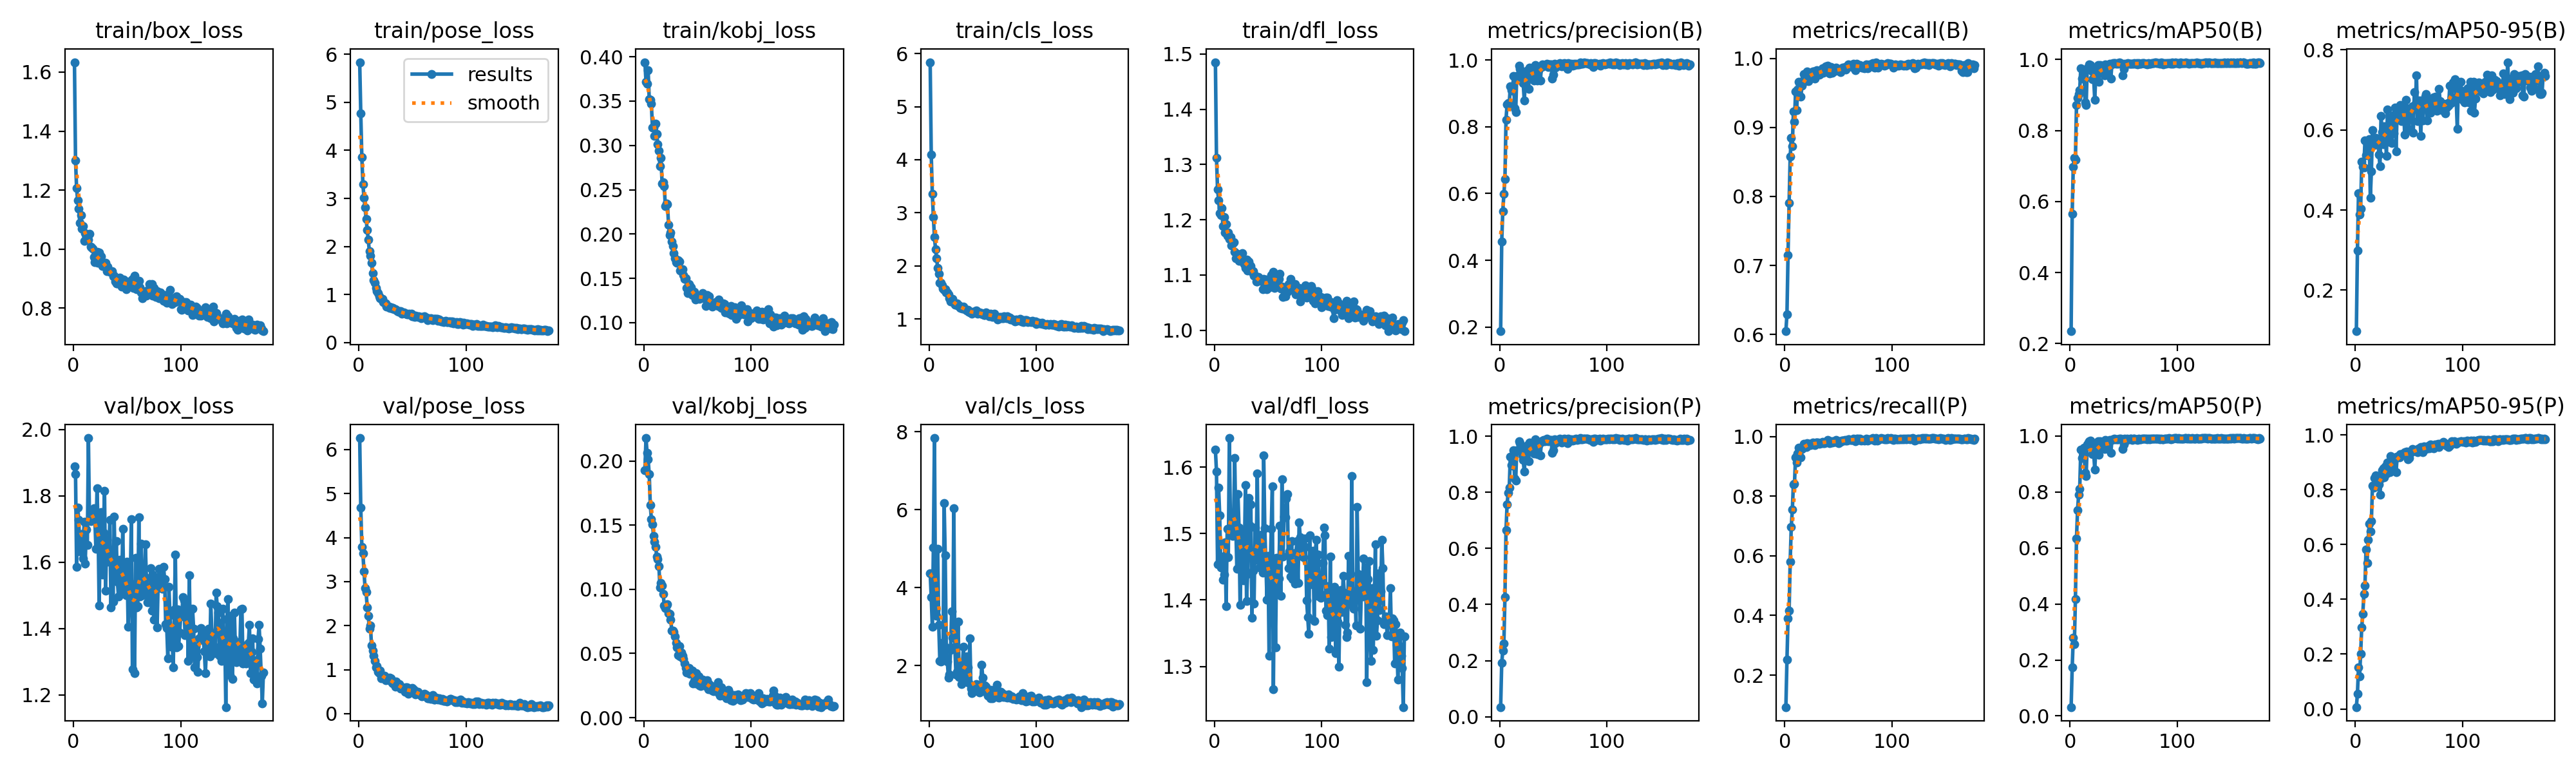

confusion_matrix_normalized.png


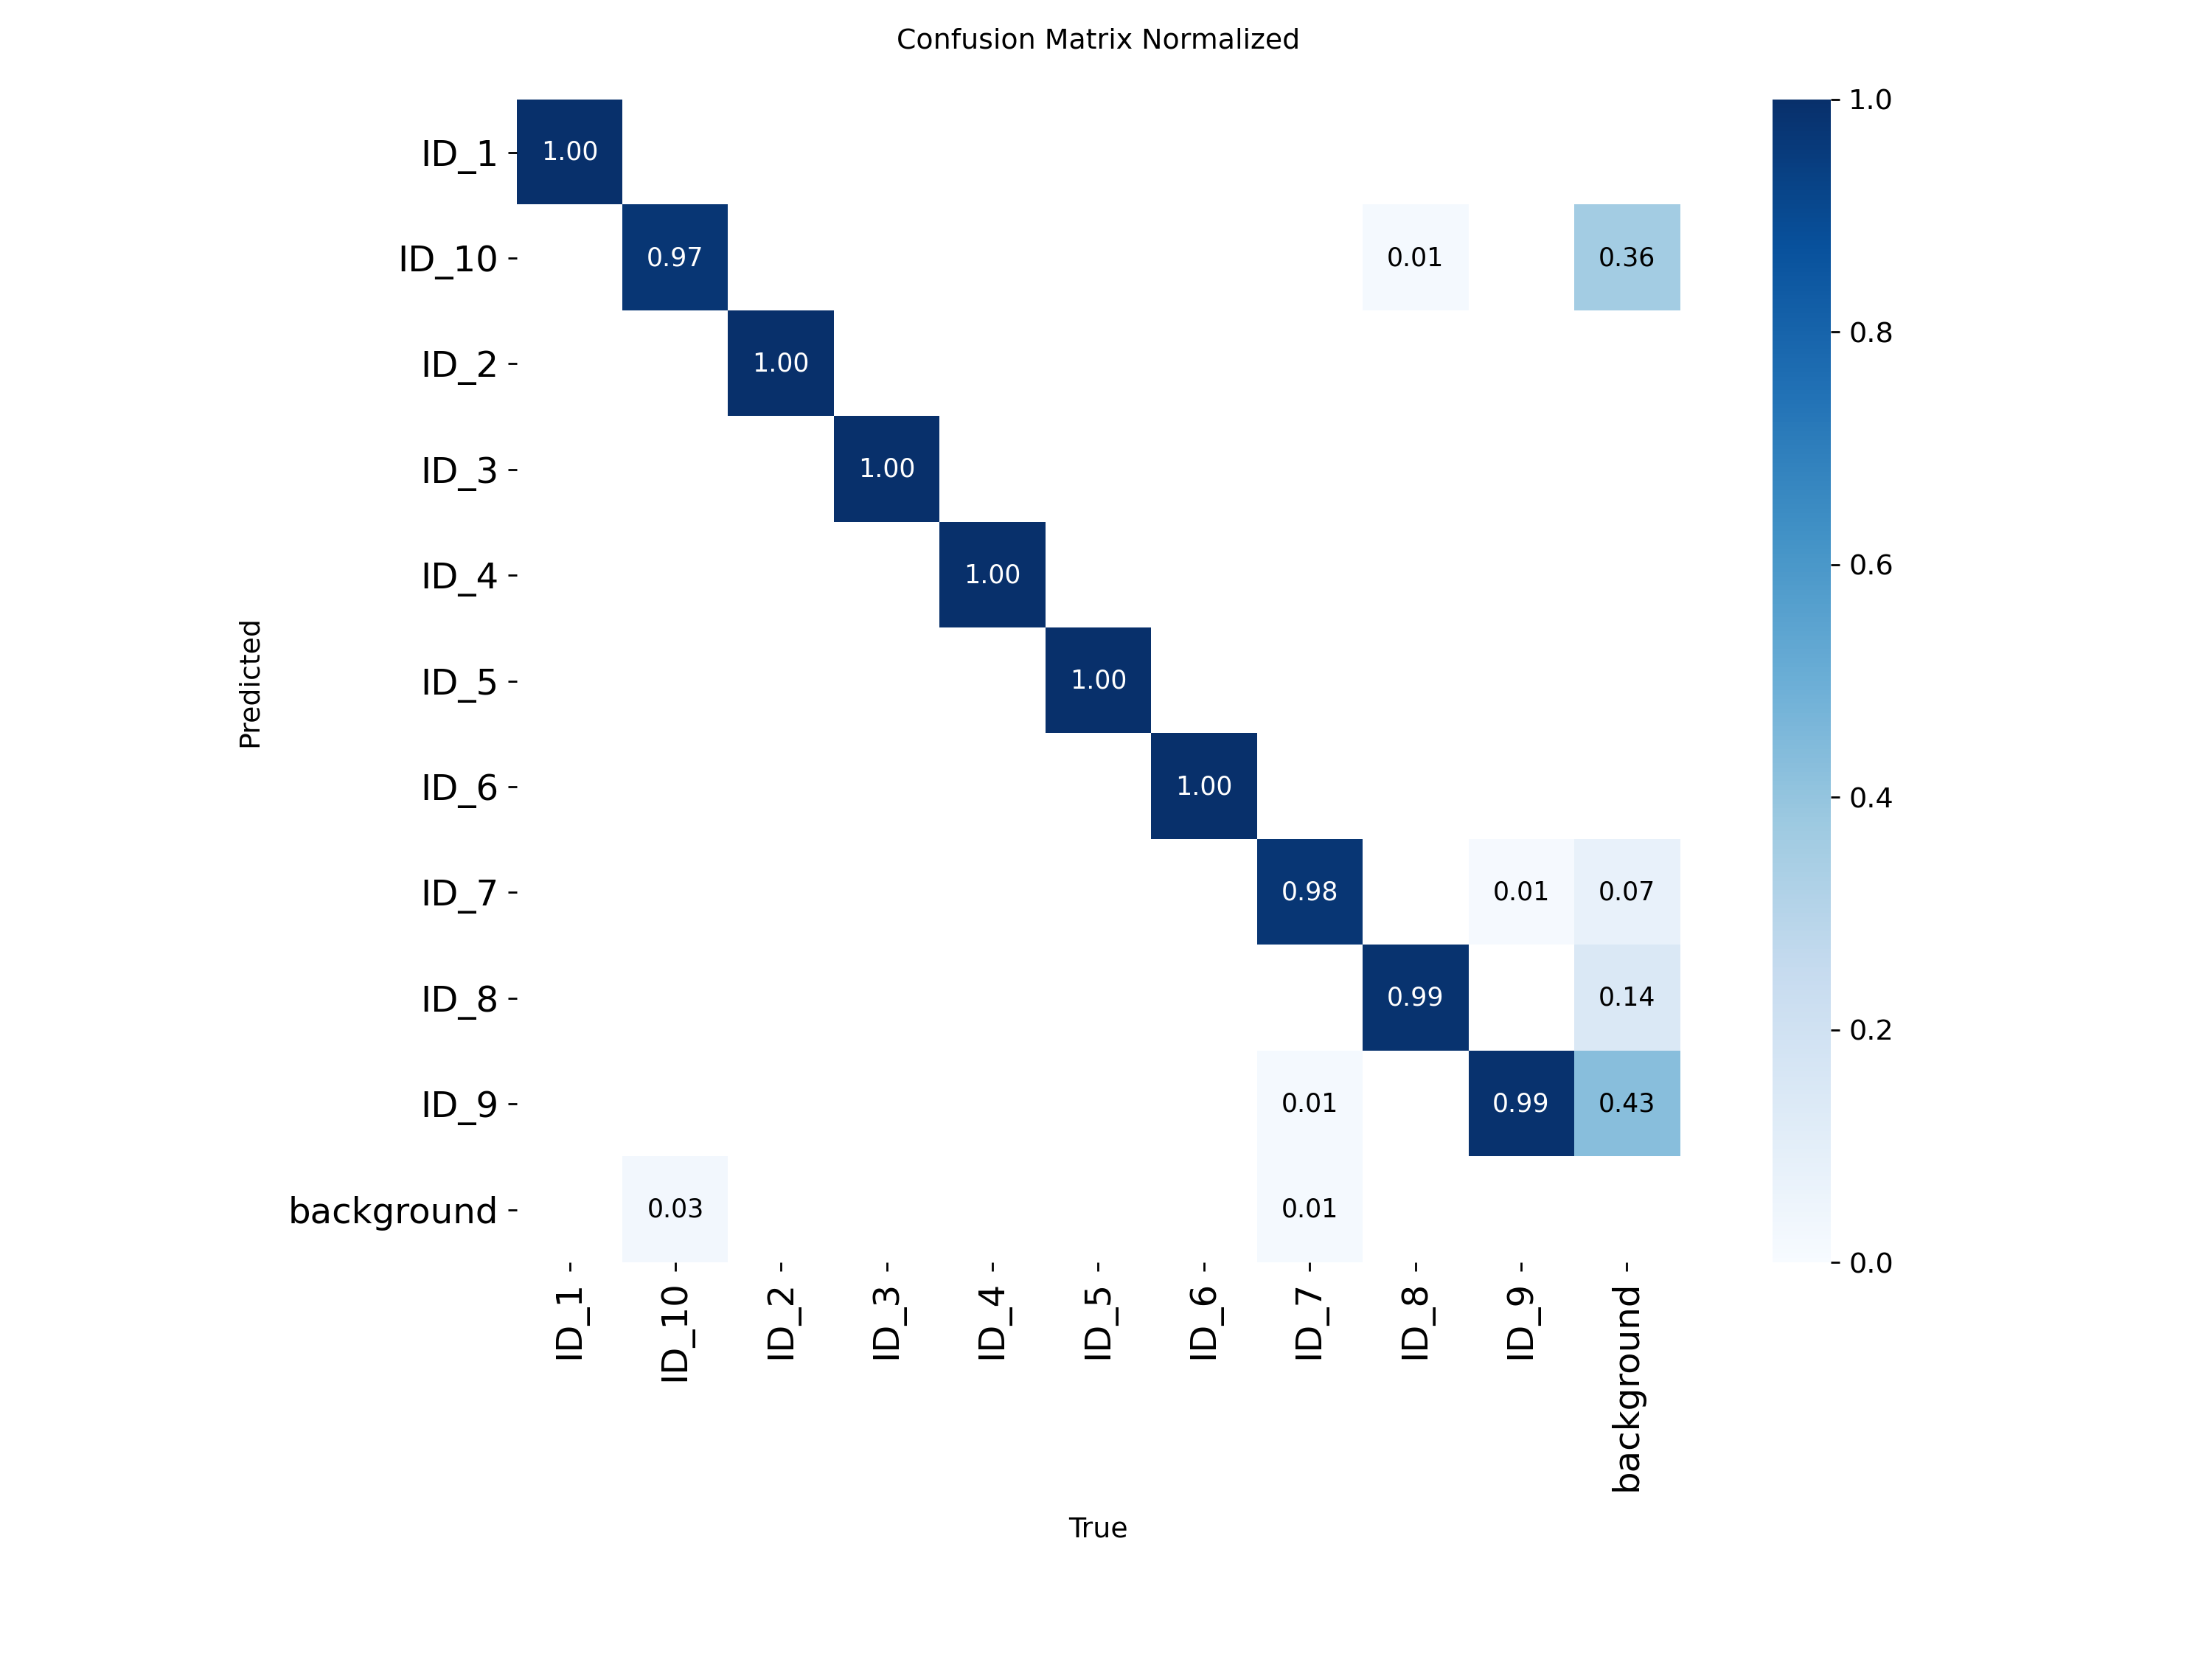

BoxPR_curve.png


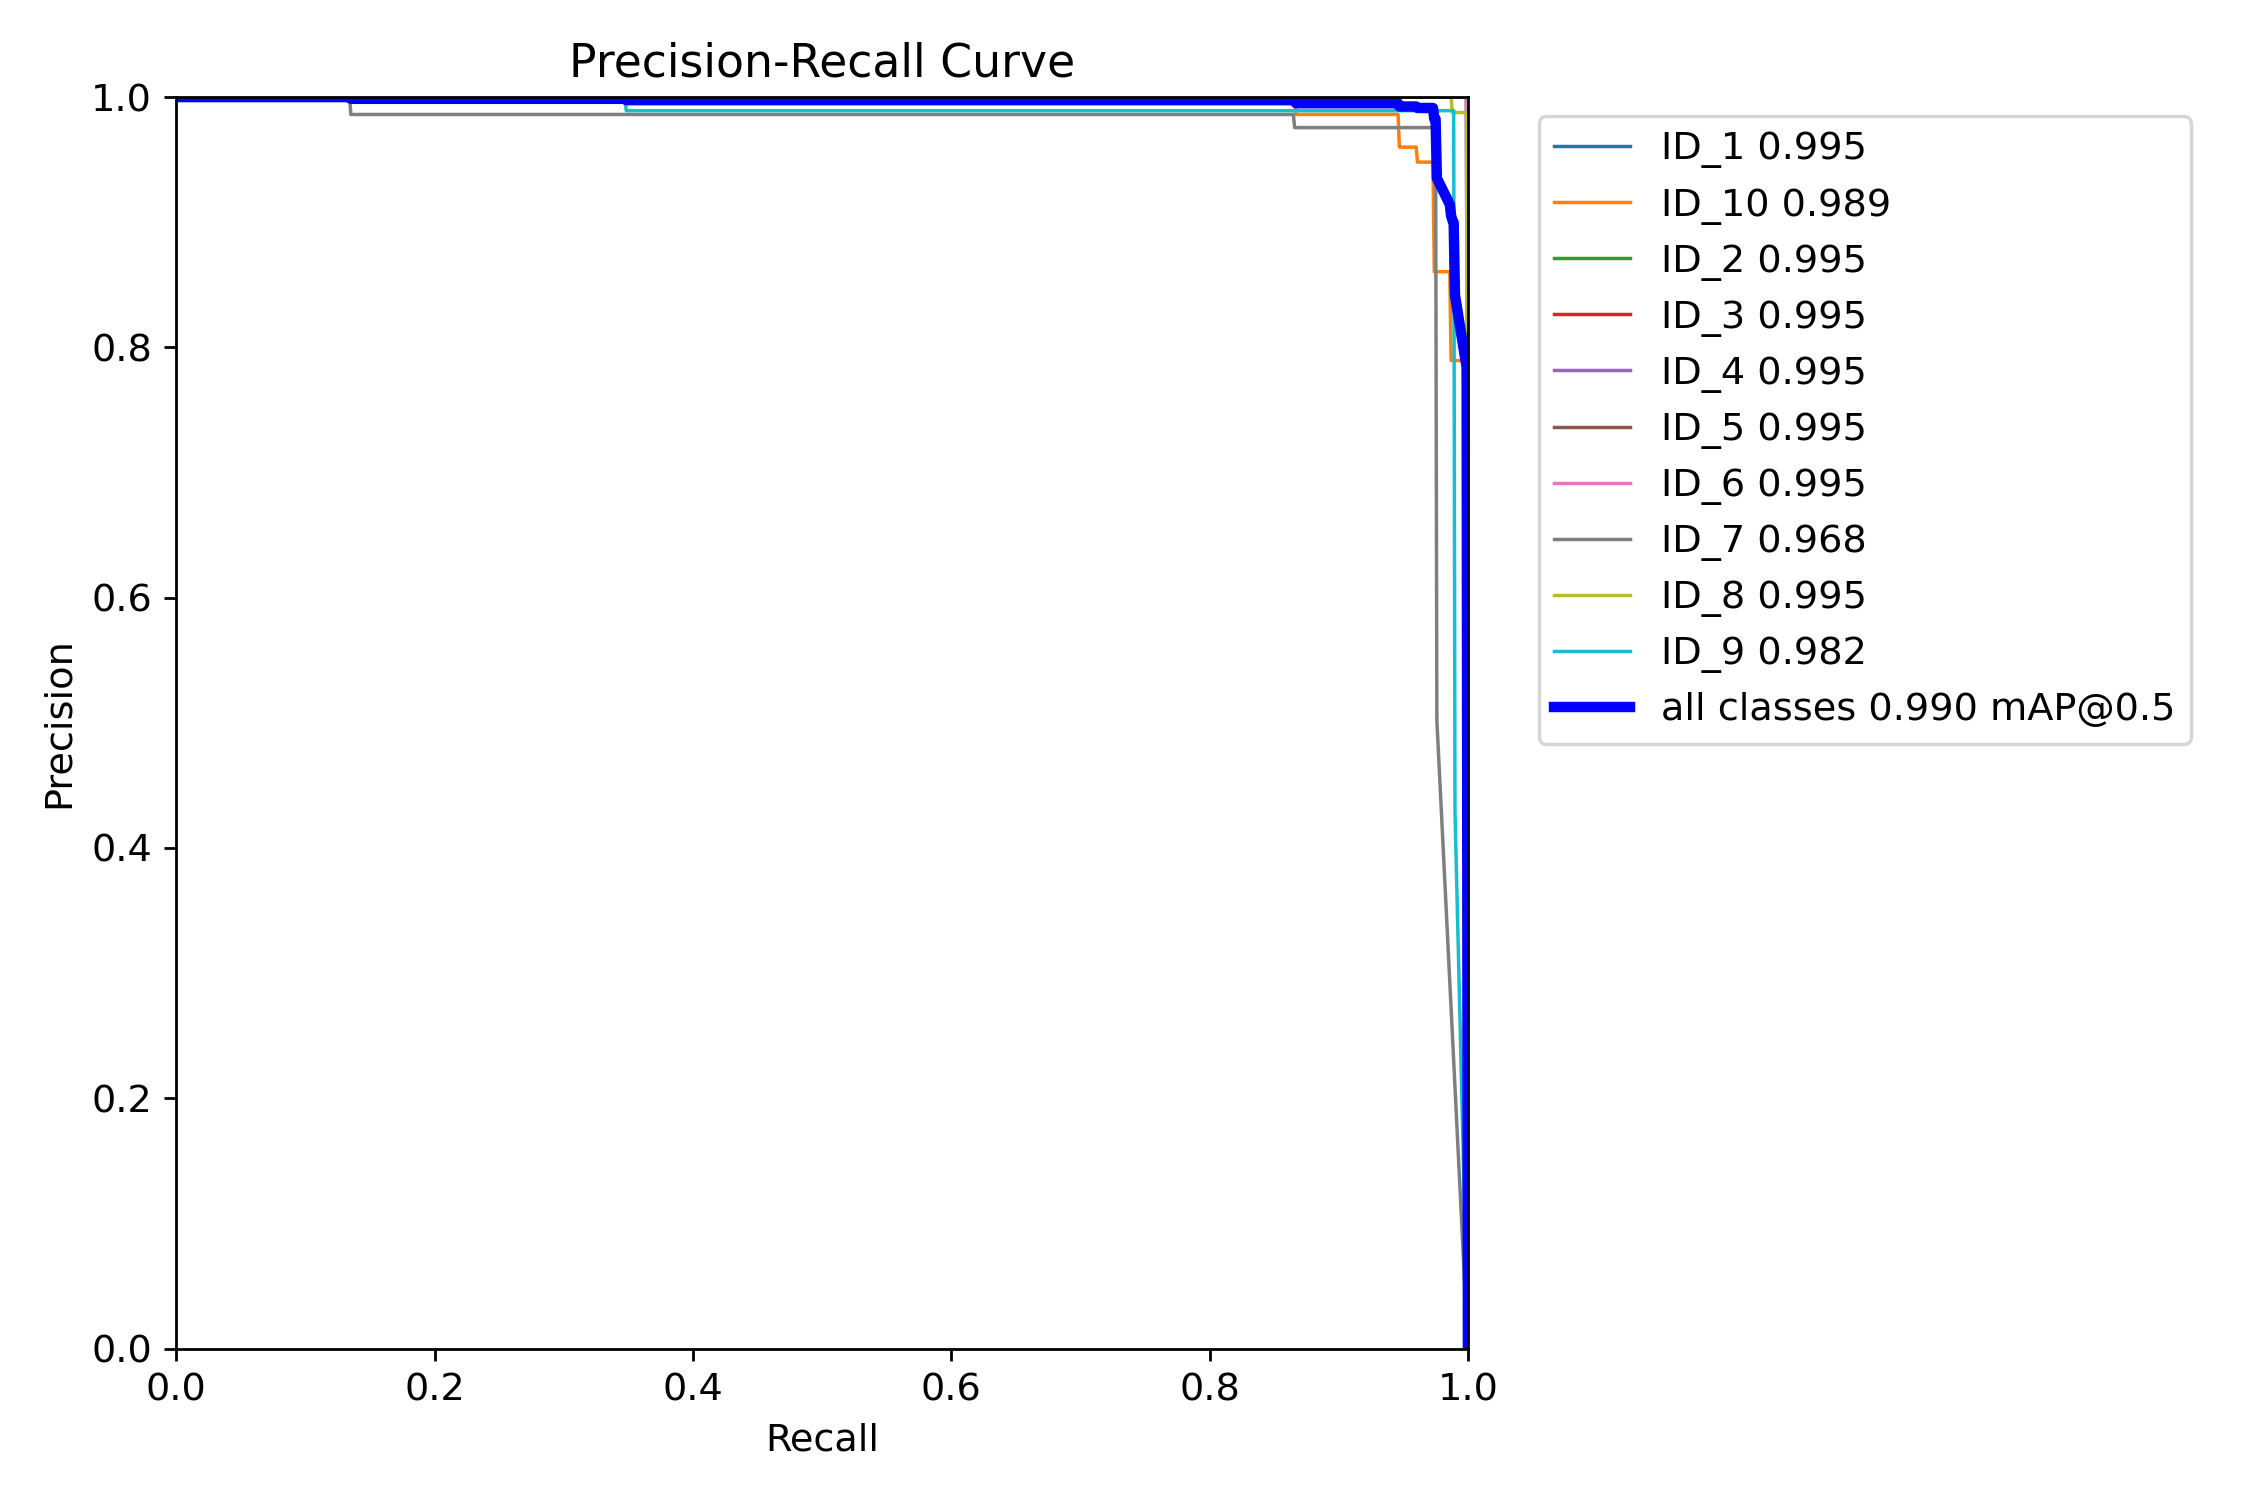

PosePR_curve.png


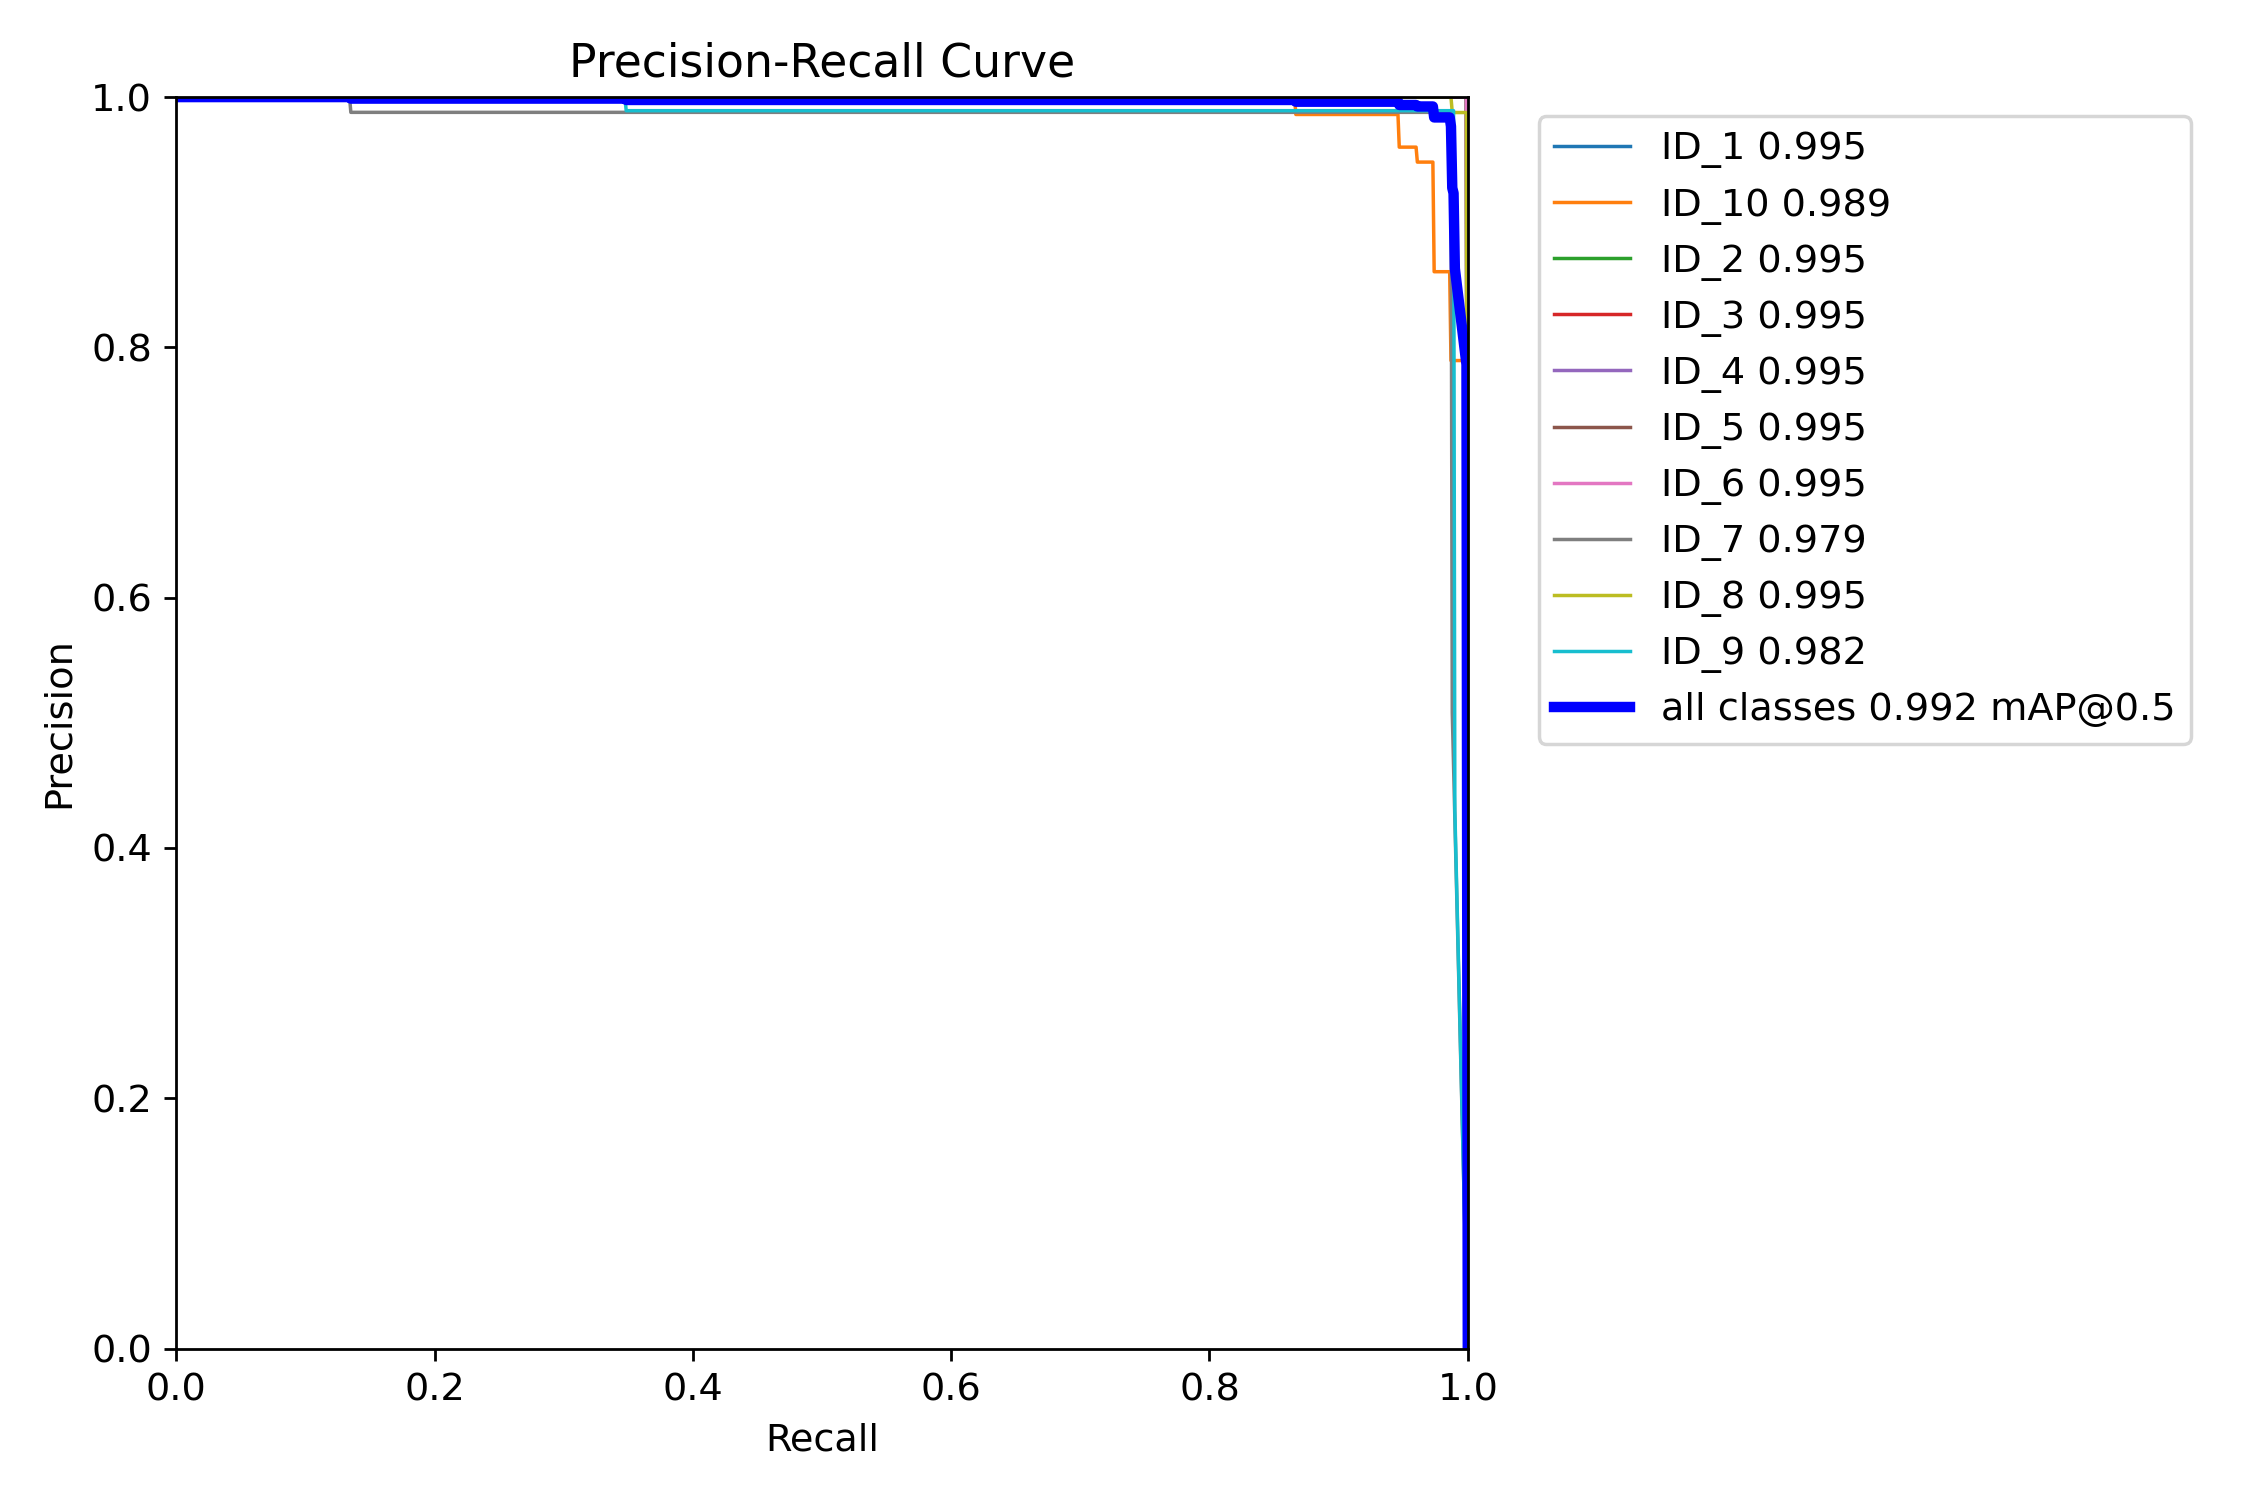

In [18]:
from ultralytics import YOLO
import os
from IPython.display import display, Image

best_weights = str(results.save_dir / 'weights' / 'best.pt')
print(f"Evaluating: {best_weights}")

eval_model = YOLO(best_weights)
metrics = eval_model.val(data=r"C:\Users\rizro\Downloads\aeromaze.v13i.yolov8\data.yaml", device=0)

print(f"\n=== Best Model — Validation Metrics ===")
print(f"  Box  mAP50:     {metrics.box.map50:.4f}")
print(f"  Box  mAP50-95:  {metrics.box.map:.4f}")
print(f"  Pose mAP50:     {metrics.pose.map50:.4f}")
print(f"  Pose mAP50-95:  {metrics.pose.map:.4f}")

names = eval_model.names
print(f"\n  Per-class Box mAP50:")
for i, ap in enumerate(metrics.box.ap50):
    print(f"    {names[i]:>6}: {ap:.4f}")

save_dir = str(results.save_dir)
for fname in ('results.png', 'confusion_matrix_normalized.png', 'BoxPR_curve.png', 'PosePR_curve.png'):
    fpath = os.path.join(save_dir, fname)
    if os.path.exists(fpath):
        print(fname)
        display(Image(fpath, width=800))